In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("screen_time_app_usage_dataset.csv")


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           3000 non-null   int64  
 1   date              3000 non-null   object 
 2   app_name          3000 non-null   object 
 3   category          3000 non-null   object 
 4   screen_time_min   3000 non-null   float64
 5   launches          3000 non-null   int64  
 6   interactions      3000 non-null   int64  
 7   is_productive     3000 non-null   bool   
 8   youtube_views     142 non-null    float64
 9   youtube_likes     142 non-null    float64
 10  youtube_comments  142 non-null    float64
 11  extra_col_11      3000 non-null   float64
 12  extra_col_12      3000 non-null   float64
 13  extra_col_13      3000 non-null   float64
 14  extra_col_14      3000 non-null   float64
 15  extra_col_15      3000 non-null   float64
 16  extra_col_16      3000 non-null   float64


In [10]:
df.head(2)

,user_id,date,app_name,category,screen_time_min,launches,interactions,is_productive,youtube_views,youtube_likes,...,extra_col_14,extra_col_15,extra_col_16,extra_col_17,extra_col_18,extra_col_19,extra_col_20,extra_col_21,extra_col_22,extra_col_23
0,1051,2024-01-01 00:00:00.000000000,Camera,Utilities,24.53,2,7,False,NaN,NaN,...,33.43,49.03,64.74,49.49,47.64,38.34,39.56,49.14,62.18,55.91
1,1088,2024-01-01 00:43:41.673891297,Chrome,Utilities,19.78,3,2,False,NaN,NaN,...,44.06,49.40,66.63,62.10,47.64,51.88,42.35,55.86,45.96,46.69


In [12]:
# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (3000, 24)

Columns: ['user_id', 'date', 'app_name', 'category', 'screen_time_min', 'launches', 'interactions', 'is_productive', 'youtube_views', 'youtube_likes', 'youtube_comments', 'extra_col_11', 'extra_col_12', 'extra_col_13', 'extra_col_14', 'extra_col_15', 'extra_col_16', 'extra_col_17', 'extra_col_18', 'extra_col_19', 'extra_col_20', 'extra_col_21', 'extra_col_22', 'extra_col_23']

Data Types:
 user_id               int64
date                 object
app_name             object
category             object
screen_time_min     float64
launches              int64
interactions          int64
is_productive          bool
youtube_views       float64
youtube_likes       float64
youtube_comments    float64
extra_col_11        float64
extra_col_12        float64
extra_col_13        float64
extra_col_14        float64
extra_col_15        float64
extra_col_16        float64
extra_col_17        float64
extra_col_18        float64
extra_col_19        float64
extra_col_20        float64


In [42]:
df.describe(include='all')

,user_id,date,app_name,category,screen_time_min,launches,interactions,is_productive,youtube_views,youtube_likes,...,extra_col_20,extra_col_21,extra_col_22,extra_col_23,year,month,day,hour,engagement_score,usage_level
count,2832.000000,2832,2832,2832,2832.000000,2832.000000,2832.000000,2832,2832.000000,2832.000000,...,2832.000000,2832.000000,2832.000000,2832.000000,2832.0,2832.000000,2832.000000,2832.000000,2832.000000,2832
unique,NaN,NaN,20,4,NaN,NaN,NaN,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,Chrome,Utilities,NaN,NaN,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,NaN,162,719,NaN,NaN,NaN,2120,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1180
mean,1049.840749,2024-02-15 12:09:45.988549888,NaN,NaN,24.611441,1.991879,4.957627,NaN,250025.887006,13009.923552,...,50.208019,50.154308,49.917553,50.170646,2024.0,2.000353,15.676907,11.477401,9.410650,NaN
min,1000.000000,2024-01-01 00:00:00,NaN,NaN,0.010000,0.000000,0.000000,NaN,1738.000000,69.000000,...,15.010000,20.040000,12.170000,15.910000,2024.0,1.000000,1.000000,0.000000,0.274000,NaN
25%,1024.000000,2024-01-23 18:43:41.673891328,NaN,NaN,8.065000,1.000000,3.000000,NaN,249747.000000,12928.500000,...,43.337500,43.427500,43.265000,43.427500,2024.0,1.000000,8.000000,5.750000,6.977500,NaN
50%,1049.000000,2024-02-15 14:11:05.021673984,NaN,NaN,19.100000,2.000000,5.000000,NaN,249747.000000,12928.500000,...,50.150000,50.015000,49.770000,50.145000,2024.0,2.000000,16.000000,11.000000,9.176000,NaN
75%,1076.000000,2024-03-09 03:48:54.978326016,NaN,NaN,36.240000,3.000000,6.000000,NaN,249747.000000,12928.500000,...,56.872500,57.032500,56.702500,56.902500,2024.0,3.000000,23.000000,18.000000,11.598500,NaN
max,1100.000000,2024-04-01 00:00:00,NaN,NaN,87.660000,9.000000,13.000000,NaN,494839.000000,43893.000000,...,86.100000,84.950000,80.810000,84.800000,2024.0,4.000000,31.000000,23.000000,24.223000,NaN


In [41]:
for i in df:
    print(i)
    print('*'*5,df[i].unique(),"*"*5)

user_id
***** [1051 1088 1052 1028 1034 1064 1063 1095 1060 1016 1044 1065 1041 1079
 1087 1003 1022 1093 1069 1056 1014 1019 1027 1048 1004 1009 1033 1023
 1061 1049 1083 1055 1012 1054 1021 1036 1085 1000 1032 1035 1059 1031
 1076 1013 1080 1062 1099 1043 1086 1058 1090 1030 1050 1001 1039 1037
 1068 1029 1011 1007 1046 1096 1042 1071 1020 1047 1005 1084 1018 1078
 1017 1077 1057 1091 1072 1081 1073 1025 1067 1045 1026 1098 1066 1053
 1008 1038 1097 1094 1006 1015 1002 1010 1075 1024 1092 1100 1074 1082
 1089 1070 1040] *****
date
***** <DatetimeArray>
[          '2024-01-01 00:00:00', '2024-01-01 00:43:41.673891297',
 '2024-01-01 01:27:23.347782594', '2024-01-01 02:11:05.021673891',
 '2024-01-01 02:54:46.695565188', '2024-01-01 03:38:28.369456485',
 '2024-01-01 04:22:10.043347782', '2024-01-01 05:05:51.717239079',
 '2024-01-01 05:49:33.391130376', '2024-01-01 06:33:15.065021673',
 ...
 '2024-03-31 16:43:03.261087029', '2024-03-31 17:26:44.934978326',
 '2024-03-31 18:10:26.608869623'

In [24]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [25]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [26]:
# Drop irrelevant or extra columns (optional)
extra_cols = [col for col in df.columns if "extra_col" in col]
df_clean = df.drop(columns=extra_cols)

# 🧮 Summary statistics
print("\nDescriptive Statistics:\n", df_clean.describe())


Descriptive Statistics:
            user_id                 date  screen_time_min     launches  \
count  3000.000000                 3000      3000.000000  3000.000000   
mean   1049.800667  2024-02-15 12:00:00        29.902057     1.993333   
min    1000.000000  2024-01-01 00:00:00         0.010000     0.000000   
25%    1024.000000  2024-01-23 18:00:00         8.617500     1.000000   
50%    1049.000000  2024-02-15 12:00:00        20.585000     2.000000   
75%    1076.000000  2024-03-09 06:00:00        40.415000     3.000000   
max    1100.000000  2024-04-01 00:00:00       218.390000     9.000000   
std      29.406369                  NaN        30.561599     1.403547   

       interactions  youtube_views  youtube_likes  youtube_comments  
count   3000.000000     142.000000     142.000000        142.000000  
mean       4.962000  256577.183099   14645.267606       2695.563380  
min        0.000000    1738.000000      69.000000          8.000000  
25%        3.000000  141490.000000  

In [27]:
# Handle missing values in numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [28]:
# Fill missing categorical columns
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [29]:
# 🔍 Check missing again
print("\nAfter cleaning:\n", df.isnull().sum())
print("Shape after cleaning:", df.shape)


After cleaning:
 user_id             0
date                0
app_name            0
category            0
screen_time_min     0
launches            0
interactions        0
is_productive       0
youtube_views       0
youtube_likes       0
youtube_comments    0
extra_col_11        0
extra_col_12        0
extra_col_13        0
extra_col_14        0
extra_col_15        0
extra_col_16        0
extra_col_17        0
extra_col_18        0
extra_col_19        0
extra_col_20        0
extra_col_21        0
extra_col_22        0
extra_col_23        0
dtype: int64
Shape after cleaning: (3000, 24)


In [30]:
# 🧮 Data Transformation
# Add new features from date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour

# Create feature: total engagement score
df['engagement_score'] = df['launches'] + df['interactions'] + (df['screen_time_min'] / 10)

# Categorize screen time
def screen_time_label(x):
    if x < 15:
        return "Low"
    elif x < 45:
        return "Medium"
    else:
        return "High"

df['usage_level'] = df['screen_time_min'].apply(screen_time_label)

# 🧩 Data Overview
print("\nData Overview:\n", df.head())


Data Overview:
    user_id                          date     app_name       category  \
0     1051 2024-01-01 00:00:00.000000000       Camera      Utilities   
1     1088 2024-01-01 00:43:41.673891297       Chrome      Utilities   
2     1052 2024-01-01 01:27:23.347782594      Spotify  Entertainment   
3     1028 2024-01-01 02:11:05.021673891  Google Maps      Utilities   
4     1034 2024-01-01 02:54:46.695565188    Instagram         Social   

   screen_time_min  launches  interactions  is_productive  youtube_views  \
0            24.53         2             7          False       249747.0   
1            19.78         3             2          False       249747.0   
2            32.03         1             6          False       249747.0   
3            19.10         2             5          False       249747.0   
4            25.19         1             5          False       249747.0   

   youtube_likes  ...  extra_col_20  extra_col_21  extra_col_22  extra_col_23  \
0        129

In [31]:
# 🎯 Outlier Detection and Removal (IQR method)
Q1 = df['screen_time_min'].quantile(0.25)
Q3 = df['screen_time_min'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['screen_time_min'] >= lower) & (df['screen_time_min'] <= upper)]

print("\nAfter removing outliers, shape:", df.shape)


After removing outliers, shape: (2832, 30)


In [32]:
# 🔢 Aggregations and Grouping
# 1️⃣ Average screen time per category
cat_usage = df.groupby('category')['screen_time_min'].mean().sort_values(ascending=False)
print("\nAverage Screen Time by Category:\n", cat_usage)


Average Screen Time by Category:
 category
Social           24.909045
Utilities        24.778581
Entertainment    24.759260
Productivity     24.002008
Name: screen_time_min, dtype: float64


In [33]:
# 2️⃣ User-wise total screen time
user_usage = df.groupby('user_id')['screen_time_min'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Users by Total Screen Time:\n", user_usage)


Top 10 Users by Total Screen Time:
 user_id
1096    1196.98
1099    1159.86
1097    1063.26
1073    1017.66
1044     977.37
1041     974.31
1056     970.55
1010     946.25
1030     943.01
1029     930.64
Name: screen_time_min, dtype: float64


In [34]:
# 3️⃣ Productivity ratio
prod_ratio = df['is_productive'].value_counts(normalize=True) * 100
print("\nProductivity App Usage Ratio (%):\n", prod_ratio)


Productivity App Usage Ratio (%):
 is_productive
False    74.858757
True     25.141243
Name: proportion, dtype: float64


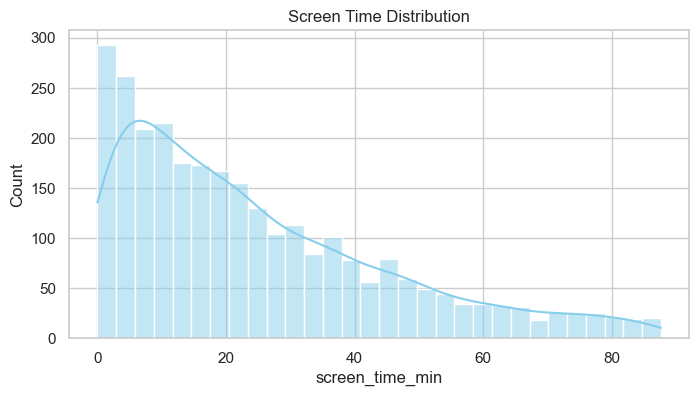

In [35]:
# 📊 Visualization Section
sns.set(style="whitegrid")

# 1️⃣ Screen Time Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['screen_time_min'], bins=30, kde=True, color='skyblue')
plt.title("Screen Time Distribution")
plt.show()

C:\Users\ANEESHA\AppData\Local\Temp\ipykernel_17488\2053071113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_usage.values, y=cat_usage.index, palette="mako")


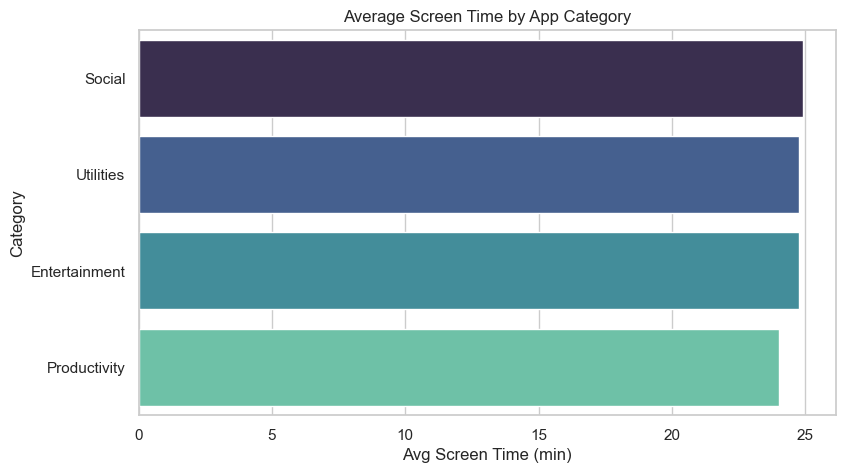

In [36]:
# 2️⃣ Category-wise average usage
plt.figure(figsize=(9,5))
sns.barplot(x=cat_usage.values, y=cat_usage.index, palette="mako")
plt.title("Average Screen Time by App Category")
plt.xlabel("Avg Screen Time (min)")
plt.ylabel("Category")
plt.show()

C:\Users\ANEESHA\AppData\Local\Temp\ipykernel_17488\2443305152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='usage_level', palette='viridis')


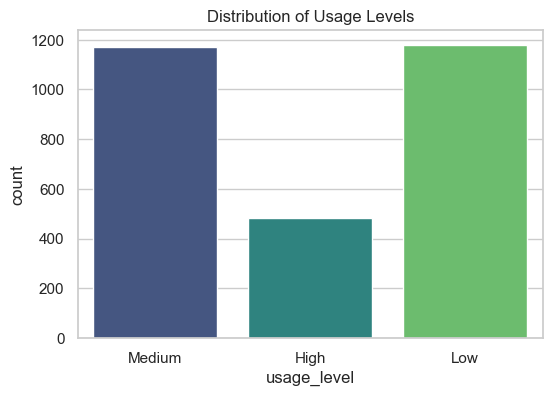

In [37]:
# 3️⃣ Usage Level Count
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='usage_level', palette='viridis')
plt.title("Distribution of Usage Levels")
plt.show()

C:\Users\ANEESHA\AppData\Local\Temp\ipykernel_17488\1259991150.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_apps.values, y=top_apps.index, palette="viridis")


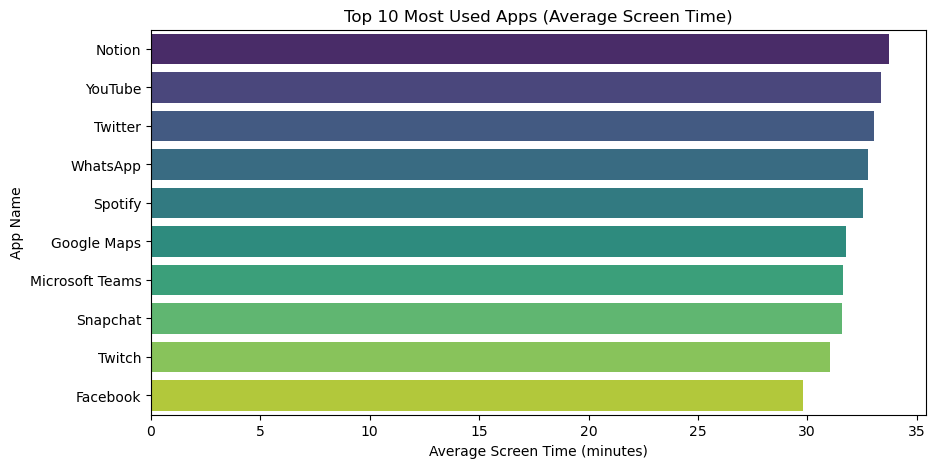

In [16]:
# 🎯 Insights 1: Top 10 most used apps by average screen time
top_apps = df_clean.groupby("app_name")["screen_time_min"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_apps.values, y=top_apps.index, palette="viridis")
plt.title("Top 10 Most Used Apps (Average Screen Time)")
plt.xlabel("Average Screen Time (minutes)")
plt.ylabel("App Name")
plt.show()

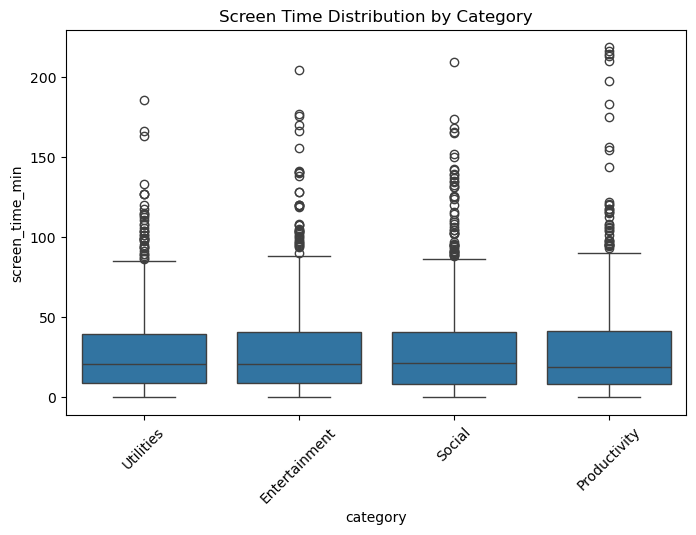

In [17]:
# 🎯 Insights 2: Usage by category
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="category", y="screen_time_min")
plt.title("Screen Time Distribution by Category")
plt.xticks(rotation=45)
plt.show()

C:\Users\ANEESHA\AppData\Local\Temp\ipykernel_17488\2497893402.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df['screen_time_min'] = pd.to_numeric(df['screen_time_min'], errors='ignore')


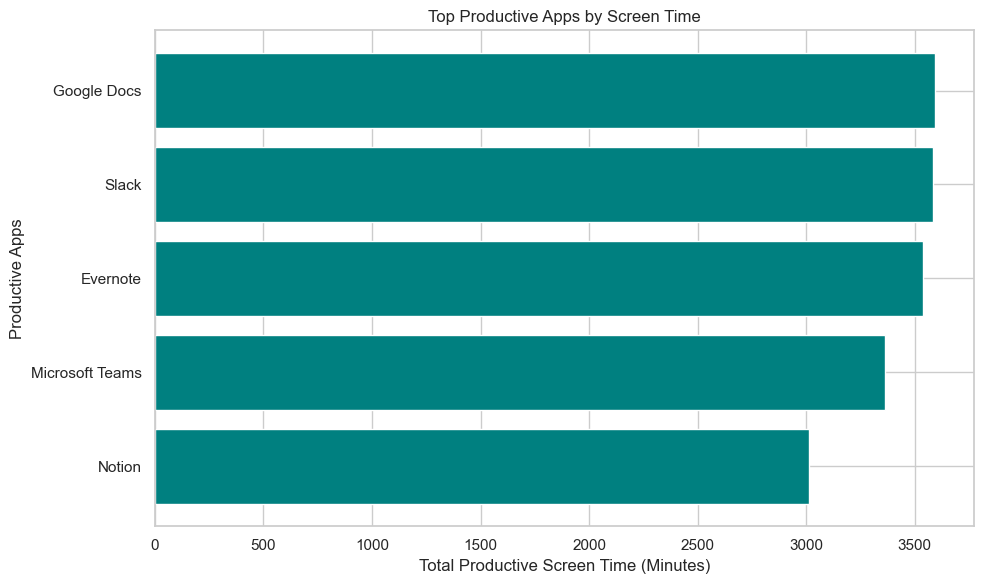

In [55]:
# Convert columns to correct types
df['screen_time_min'] = pd.to_numeric(df['screen_time_min'], errors='ignore')
df['is_productive'] = df['is_productive'].astype(bool)

# Filter only productive apps
productive_df = df[df['is_productive'] == True]

# Group by app and calculate total productive screen time
productive_apps = (productive_df.groupby('app_name')['screen_time_min']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))   # Top 10 productive apps

# Plot
plt.figure(figsize=(10,6))
plt.barh(productive_apps.index[::-1], 
         productive_apps.values[::-1], 
         color="teal")   # 👉 CHANGE COLOR HERE

plt.xlabel("Total Productive Screen Time (Minutes)")
plt.ylabel("Productive Apps")
plt.title("Top Productive Apps by Screen Time")
plt.tight_layout()
plt.show()


C:\Users\ANEESHA\AppData\Local\Temp\ipykernel_17488\3475590008.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df['screen_time_min'] = pd.to_numeric(df['screen_time_min'], errors='ignore')


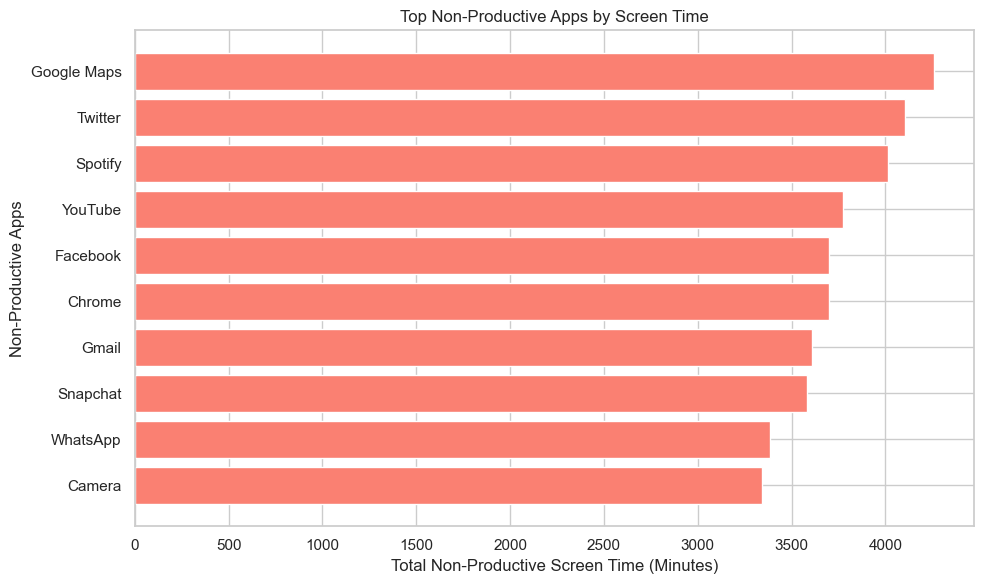

In [56]:
# Convert columns to correct types
df['screen_time_min'] = pd.to_numeric(df['screen_time_min'], errors='ignore')
df['is_productive'] = df['is_productive'].astype(bool)

# Filter only NON-productive apps
non_productive_df = df[df['is_productive'] == False]

# Group by app and calculate total non-productive screen time
non_productive_apps = (non_productive_df.groupby('app_name')['screen_time_min']
                        .sum()
                        .sort_values(ascending=False)
                        .head(10))   # Top 10 non-productive apps

# Plot
plt.figure(figsize=(10,6))
plt.barh(non_productive_apps.index[::-1], 
         non_productive_apps.values[::-1], 
         color="salmon")   # 👉 Choose any color

plt.xlabel("Total Non-Productive Screen Time (Minutes)")
plt.ylabel("Non-Productive Apps")
plt.title("Top Non-Productive Apps by Screen Time")
plt.tight_layout()
plt.show()


C:\Users\ANEESHA\AppData\Local\Temp\ipykernel_17488\3803573817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="is_productive", y="screen_time_min", palette="coolwarm")


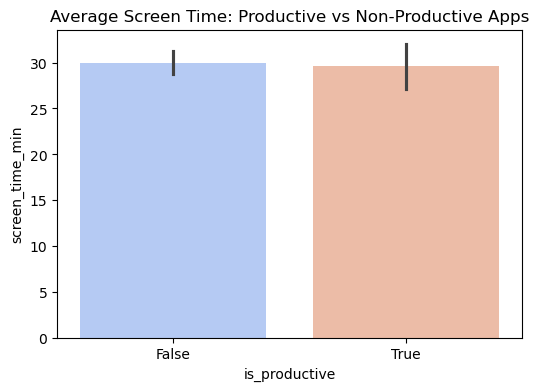

In [18]:
# 🎯 Insights 3: Productive vs Non-Productive screen time
plt.figure(figsize=(6,4))
sns.barplot(data=df_clean, x="is_productive", y="screen_time_min", palette="coolwarm")
plt.title("Average Screen Time: Productive vs Non-Productive Apps")
plt.show()


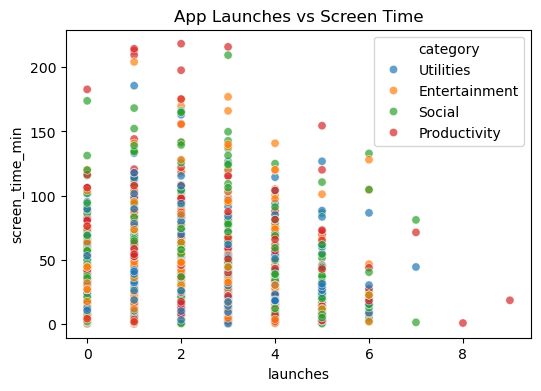

In [19]:
# 🎯 Insights 4: Relationship between app launches & screen time
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x="launches", y="screen_time_min", hue="category", alpha=0.7)
plt.title("App Launches vs Screen Time")
plt.show()

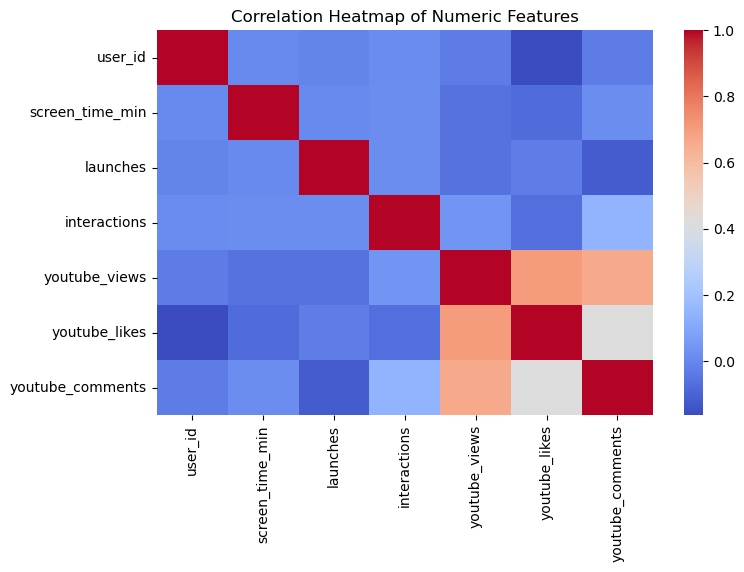

In [20]:
# 🎯 Insights 5: Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df_clean.select_dtypes('number').corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

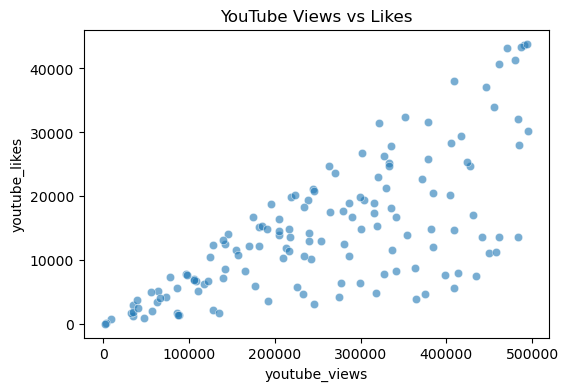

In [21]:
# 🎯 Insights 6: YouTube activity (if present)
youtube_df = df_clean.dropna(subset=["youtube_views"])
if not youtube_df.empty:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=youtube_df, x="youtube_views", y="youtube_likes", alpha=0.6)
    plt.title("YouTube Views vs Likes")
    plt.show()

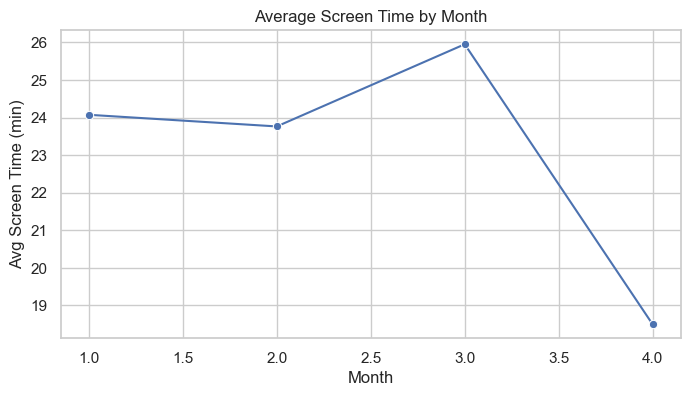

In [40]:
# 7️⃣ Monthly Trend (if multiple months)
if df['month'].nunique() > 1:
    monthly = df.groupby('month')['screen_time_min'].mean()
    plt.figure(figsize=(8,4))
    sns.lineplot(x=monthly.index, y=monthly.values, marker="o")
    plt.title("Average Screen Time by Month")
    plt.xlabel("Month")
    plt.ylabel("Avg Screen Time (min)")
    plt.show()